In [ ]:
'''
1. Load dataset
       ↓
2. Basic statistics / inspection
       ↓
3. Missing values
       ↓
4. Duplicate values
       ↓
5. Invalid values
       ↓
6. Outlier analysis
       ↓
7. Target distribution (loan_status)
       ↓
8. Feature engineering
       ↓
9. Train/test split
       ↓
10. Categorical encoding
       ↓
11. Scaling (if required by model)
       ↓
12. Train XGBoost
       ↓
13. Evaluate'''

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#Dataset Information 

df = pd.read_csv("credit_risk_dataset.csv")

print("Shape:", df.shape)

print("\nData Types:", df.dtypes)

print("\nFirst 5 rows:", df.head())

print("\nBasic Statistics:", df.describe())

print("\nMissing Values:", df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (32581, 12)

Data Types: person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

First 5 rows:    person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_in

In [4]:
#Dealing with missing values and duplicates

df = df.drop_duplicates()

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

df = df.dropna(subset = ['person_emp_length']) 

#Dataset information after cleaning

print("\nShape:", df.shape)

print("\nMissing Values:", df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Shape: (31529, 12)

Missing Values: person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Duplicate Rows: 0


In [5]:
#Checking for invalid values in categorical columns

print("Age < 0:\n", df[df['person_age'] < 0].shape[0])

print("Income < 0:\n", df[df['person_income'] < 0].shape[0])

print("Loan Amount < 0:\n", df[df['loan_amnt'] < 0].shape[0])

print("Employment Length < 0:\n", df[df['person_emp_length'] < 0].shape[0])

print("Loan Interest Rate < 0:\n", df[df['loan_int_rate'] < 0].shape[0])

print("Unique Values in Home Ownership:\n", df['person_home_ownership'].unique())

print("Unique Values in Loan Status:\n", df['loan_status'].unique())

print("Unique Values in Default Status:\n", df['cb_person_default_on_file'].unique())

Age < 0:
 0
Income < 0:
 0
Loan Amount < 0:
 0
Employment Length < 0:
 0
Loan Interest Rate < 0:
 0
Unique Values in Home Ownership:
 <StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
Unique Values in Loan Status:
 [1 0]
Unique Values in Default Status:
 <StringArray>
['Y', 'N']
Length: 2, dtype: str


C:\Users\arjun\AppData\Local\Temp\ipykernel_23580\3732150666.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['person_age'], vert=False)


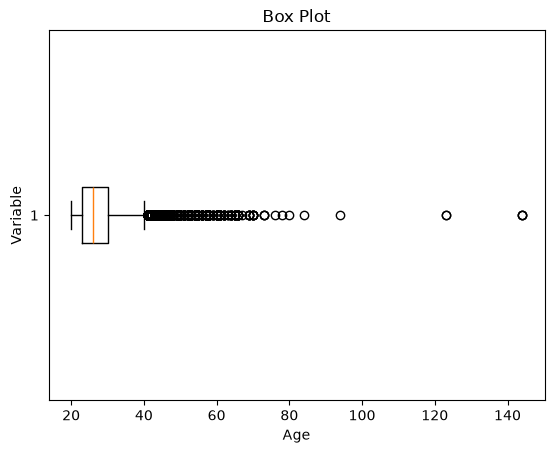

C:\Users\arjun\AppData\Local\Temp\ipykernel_23580\3732150666.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['person_emp_length'], vert=False)


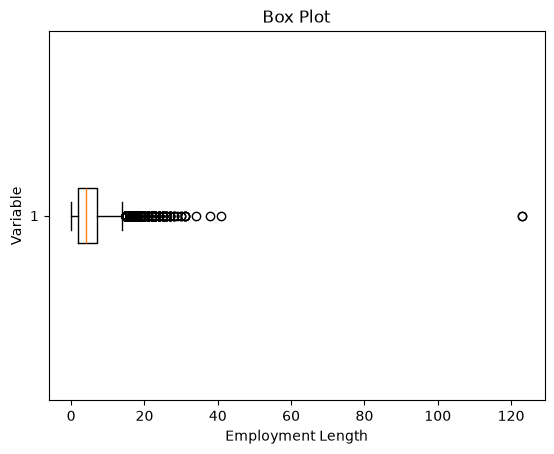

C:\Users\arjun\AppData\Local\Temp\ipykernel_23580\3732150666.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['loan_amnt'], vert=False)


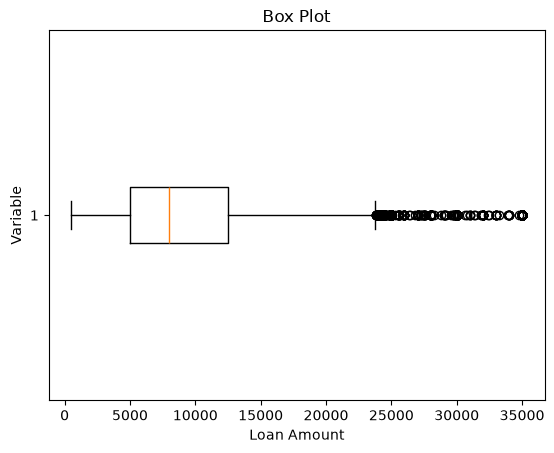

In [6]:
#Checking for Outliers 

plt.boxplot(df['person_age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

plt.boxplot(df['person_emp_length'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Employment Length')
plt.title('Box Plot')
plt.show()

plt.boxplot(df['loan_amnt'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Loan Amount')
plt.title('Box Plot')
plt.show()

In [7]:
#Eliminating Extreme Outliers

df_updated = df[(df['person_age'] >= 18) & (df['person_age'] <= 100) &
                (df['person_emp_length'] >= 0) & (df['person_emp_length'] <= 40)]

print("After eliminating extreme outliers : \n")
print("Shape: ", df_updated.shape)
print("Missing Values: ", df_updated.isnull().sum())
print("Duplicate Rows: ", df_updated.duplicated().sum())

After eliminating extreme outliers : 

Shape:  (31521, 12)
Missing Values:  person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
Duplicate Rows:  0


In [ ]:
#Feature Transformation and Engineering 

